# 02 — Reconstruction analysis

Loads a trained checkpoint and inspects reconstruction quality and latent-space health interactively.

This notebook complements `src/evaluate.py`: the script is the reproducible, scripted evaluation path (used for the numbers in `docs/RESULTS.md`); this notebook is for interactively looking at *why* a run behaves the way it does — e.g. spotting posterior collapse or blurry reconstructions before running the full analysis pipeline.

**Before running:** train a model first, e.g.
```bash
python -m src.train --config configs/crc_vae_pilot_cpu.yaml
```
then set `CONFIG_PATH` and `CHECKPOINT_PATH` below.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(Path.cwd().parents[0]))

from src.analysis.evaluation import evaluate_representation_model
from src.analysis.latent import compute_latent_diagnostics
from src.datasets.factory import build_evaluation_data_loader, prepare_metadata
from src.models.factory import build_model_from_config
from src.training.visualization import create_reconstruction_grid
from src.utils.config import load_config
from src.utils.device import resolve_device
from src.evaluate import load_model_weights

In [4]:
CONFIG_PATH = Path("./configs/crc_vae_pilot_cpu.yaml")
CHECKPOINT_PATH = Path(
    "./outputs/runs/20260717_014159_crc_pilot_color_denoising_vae_beta_1/checkpoints/best_checkpoint.pt"
)
SPLIT = "test"

config = load_config(CONFIG_PATH)
runtime = resolve_device(
    accelerator=config["device"]["accelerator"],
    mixed_precision=False,
    pin_memory=config["data"]["pin_memory"],
)

metadata = prepare_metadata(config)
data_loader = build_evaluation_data_loader(
    config=config,
    metadata=metadata,
    split=SPLIT,
    pin_memory=runtime.pin_memory,
)

model = build_model_from_config(config=config, target_device=runtime.device)
load_model_weights(model=model, checkpoint_path=CHECKPOINT_PATH, device=runtime.device)
model.eval()

ConvolutionalVAE(
  (encoder): ConvolutionalEncoder(
    (backbone): Sequential(
      (0): DownsampleBlock(
        (block): Sequential(
          (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (1): GroupNorm(8, 16, eps=1e-05, affine=True, bias=True)
          (2): SiLU()
        )
      )
      (1): DownsampleBlock(
        (block): Sequential(
          (0): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
          (2): SiLU()
        )
      )
      (2): DownsampleBlock(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
          (2): SiLU()
        )
      )
      (3): DownsampleBlock(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False

## Reconstruction grid

Rows: originals / reconstructions / absolute error.

Text(0.5, 1.0, 'test split — originals / reconstructions / |error|')

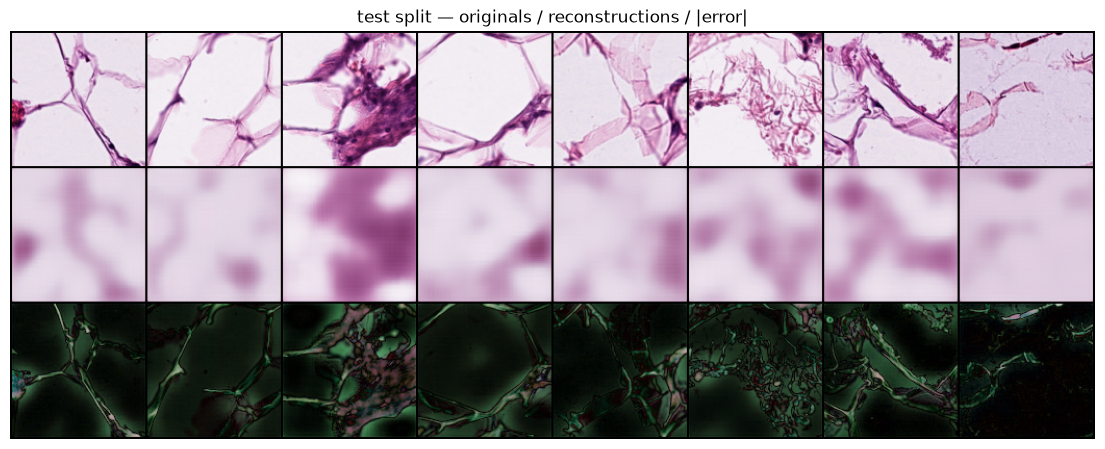

In [5]:
grid = create_reconstruction_grid(
    model=model,
    data_loader=data_loader,
    runtime=runtime,
    number_of_images=8,
)

plt.figure(figsize=(14, 6))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
plt.axis("off")
plt.title(f"{SPLIT} split — originals / reconstructions / |error|")

## Aggregate reconstruction metrics and latent diagnostics

In [6]:
evaluation_result = evaluate_representation_model(
    model=model,
    data_loader=data_loader,
    runtime=runtime,
    split_name=SPLIT,
)

print(evaluation_result.reconstruction_metrics)

diagnostics = compute_latent_diagnostics(
    latent_vectors=evaluation_result.latent_vectors,
    log_var=evaluation_result.log_var,
)

print(diagnostics.summary())

if diagnostics.number_of_active_units == 0:
    print(
        "WARNING: no active latent units — this usually "
        "means posterior collapse (beta too high, or too "
        "few KL warm-up epochs)."
    )

ReconstructionMetrics(mse=0.01904348287317488, mae=0.10296913630432553, psnr=18.44125749133916, ssim=0.2860196552508407, number_of_images=1800)
{'number_of_dimensions': 32, 'number_of_active_units': 32, 'active_fraction': 1.0, 'number_of_low_kl_dimensions': 0, 'mean_kl_per_dimension': 1.2529643774032593}


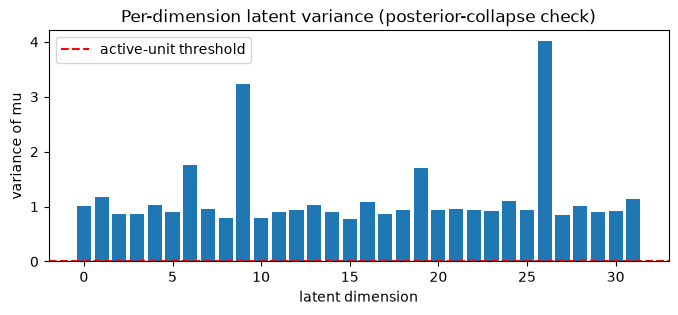

In [7]:
plt.figure(figsize=(8, 3))
plt.bar(
    range(diagnostics.number_of_dimensions),
    diagnostics.variance_of_embedding.numpy(),
)
plt.axhline(0.001, color="red", linestyle="--", label="active-unit threshold")
plt.xlabel("latent dimension")
plt.ylabel("variance of mu")
plt.title("Per-dimension latent variance (posterior-collapse check)")
plt.legend()